Import Model Configuration
==========================

In [1]:
import yaml

model_cfg = "maskrcnn.yaml"

with open("./configs/" + model_cfg , "r") as f:
    cfg = yaml.safe_load(f)

cfg['experiment_name']

'maskrcnn_baseline'

Dataset Class
=============

In [2]:
import os
import torch
from torch.utils.data import Dataset
from torchvision.io import read_image
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask
import numpy as np


class COCOSegmentationDataset(Dataset):
    def __init__(self, root_dir, transforms=None):
        self.root_dir = root_dir
        self.transforms = transforms

        # path to the JSON annotation file
        self.ann_path = os.path.join(root_dir, "_annotations.coco.json")
        self.coco = COCO(self.ann_path)
        self.ids = list(self.coco.imgs.keys())

    def __getitem__(self, index):
        coco = self.coco
        img_id = self.ids[index]
        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.root_dir, img_info['file_name'])

        img = read_image(img_path)  # shape: [C, H, W]
        img = tv_tensors.Image(img)
        h, w = img.shape[-2:]

        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        masks = []
        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for ann in anns:
            if 'segmentation' not in ann:
                continue

            rles = coco_mask.frPyObjects(ann['segmentation'], h, w)
            mask = coco_mask.decode(rles)
            if mask.ndim == 3:
                mask = mask.any(axis=2)
            mask = torch.as_tensor(mask, dtype=torch.uint8)
            masks.append(mask)

            x, y, bw, bh = ann['bbox']
            boxes.append(torch.tensor([x, y, x + bw, y + bh], dtype=torch.float32))
            labels.append(ann.get('category_id', 1))
            areas.append(ann['area'])
            iscrowd.append(ann.get('iscrowd', 0))

        if masks:
            masks = torch.stack(masks)
            boxes = torch.stack(boxes)
            labels = torch.tensor(labels, dtype=torch.int64)
            areas = torch.tensor(areas, dtype=torch.float32)
            iscrowd = torch.tensor(iscrowd, dtype=torch.int64)
        else:
            masks = torch.zeros((0, h, w), dtype=torch.uint8)
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=(h, w)),
            "masks": tv_tensors.Mask(masks),
            "labels": labels,
            "image_id": img_id,
            "area": areas,
            "iscrowd": iscrowd
        }

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        return len(self.ids)


In [3]:
from torchvision.transforms import v2 as T


def get_transform(train):
    transforms = []
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
    transforms.append(T.ToDtype(torch.float, scale=True))
    transforms.append(T.ToPureTensor())
    return T.Compose(transforms)

Train
=====

In [4]:
import utils  # Your helper functions (make sure it includes `collate_fn` from PyTorch references)
import torch
from torchvision.transforms import v2 as T
from engine import train_one_epoch, evaluate

from tqdm import tqdm
import sys
import time
from datetime import datetime

from models import MODEL_REGISTRY

from torch.utils.tensorboard import SummaryWriter

timestamp = datetime.now().strftime("%Y%m%d_%H%M")

writer = SummaryWriter(log_dir=f"runs/{cfg['experiment_name']}_{timestamp}")



device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# COCO-style dataset using your structure
dataset = COCOSegmentationDataset(
    root_dir="../../../BubANN_GAN.v1i.coco-segmentation/train",
    transforms=get_transform(train=True)
)

dataset_valid = COCOSegmentationDataset(
    root_dir="../../../BubANN_GAN.v1i.coco-segmentation/valid",
    transforms=get_transform(train=False)
)

dataset_test = COCOSegmentationDataset(
    root_dir="../../../BubANN_GAN.v1i.coco-segmentation/test",
    transforms=get_transform(train=False)
)


print("Train size:", len(dataset))
print("Validation size:", len(dataset_valid))
print("Test size:", len(dataset_test))

# Dataloaders
data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=cfg["train"]["batch_size"],
    shuffle=True,
    num_workers=4,
    collate_fn=utils.collate_fn
)

data_loader_valid = torch.utils.data.DataLoader(
    dataset_valid,
    batch_size=1,
    shuffle=False,
    num_workers=4,
    collate_fn=utils.collate_fn
)

data_loader_test = torch.utils.data.DataLoader(
    dataset_test,
    batch_size=1,
    shuffle=False,
    num_workers=4,
    collate_fn=utils.collate_fn
)

# Two classes: background + foreground
num_classes = cfg['num_classes']

# Load model
model = MODEL_REGISTRY[cfg["model"]](num_classes=cfg["num_classes"])
#model = get_model_instance_segmentation(num_classes)

model.to(device)

# Optimizer and LR scheduler from config
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params,
    lr=cfg["train"]["lr"],
    momentum=cfg["train"]["momentum"],
    weight_decay=cfg["train"]["weight_decay"],
)
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=cfg["train"]["lr_step_size"],
    gamma=cfg["train"]["gamma"],
)


num_epochs = cfg['train']['epochs']
print("Start training...")

#scaler = torch.cuda.amp.GradScaler()  # Enable AMP if you want (optional)
scaler = torch.amp.GradScaler()  # Updated for modern AMP


cfg["output_dir"] = f"outputs/{cfg['experiment_name']}_{timestamp}"
os.makedirs(cfg["output_dir"], exist_ok=True)

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    sys.stdout.flush()

    start_time = time.time()

    # tqdm-wrapped version of the training loop
    model.train()
    metric_logger = utils.MetricLogger(delimiter="  ")
    metric_logger.add_meter("lr", utils.SmoothedValue(window_size=1, fmt="{value:.6f}"))

    header = f"Epoch: [{epoch}]"

    # Optional warmup scheduler for the first epoch
    warmup_scheduler = None
    if epoch == 0:
        warmup_factor = 1.0 / 1000
        warmup_iters = min(1000, len(data_loader) - 1)
        warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
            optimizer, start_factor=warmup_factor, total_iters=warmup_iters
        )

    for batch_idx, (images, targets) in enumerate(tqdm(data_loader, desc=header)):
        images = list(img.to(device) for img in images)
        #targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets]

        # Mixed precision (optional)
        #with torch.cuda.amp.autocast(enabled=False):  # Set to True to enable AMP
        with torch.amp.autocast(device_type='cuda', enabled=False):  # Set to True to enable AMP
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        # Check for NaN or inf loss
        if not torch.isfinite(losses):
            print(f"[!] Loss is {losses.item()}, stopping training")
            print(loss_dict)
            sys.exit(1)

        optimizer.zero_grad()
        # AMP (uncomment if you enable autocast)
        # scaler.scale(losses).backward()
        # scaler.step(optimizer)
        # scaler.update()

        losses.backward()
        optimizer.step()

        if warmup_scheduler is not None:
            warmup_scheduler.step()

        metric_logger.update(loss=losses.item(), **loss_dict)
        metric_logger.update(lr=optimizer.param_groups[0]["lr"])

        # Log to TensorBoard
        global_step = epoch * len(data_loader) + batch_idx
        writer.add_scalar("Train/Loss", losses.item(), global_step)
        writer.add_scalar("Train/LR", optimizer.param_groups[0]["lr"], global_step)

    lr_scheduler.step()
    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1} completed in {epoch_time:.2f} seconds.")
    
    # Validation
    print("Evaluating on validation set:")
    val_metrics = evaluate(model, data_loader_valid, device=device)

    # If your evaluate() function returns a dict of metrics
    if isinstance(val_metrics, dict):
        for key, value in val_metrics.items():
            writer.add_scalar(f"Val/{key}", value, epoch)

    
    # Create output directory if it doesn't exist
    os.makedirs(cfg["output_dir"], exist_ok=True)
    
    # Save model weights
    torch.save(model.state_dict(), os.path.join(cfg["output_dir"], f"model_epoch_{epoch+1}.pth"))
    
    # Optionally: save full checkpoint (model + optimizer + scheduler + epoch)
    checkpoint = {
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'lr_scheduler_state_dict': lr_scheduler.state_dict(),
    }
    torch.save(checkpoint, os.path.join(cfg["output_dir"], f"checkpoint_epoch_{epoch+1}.pth"))

writer.close()

print("\nThat's it!")

loading annotations into memory...
Done (t=0.22s)
creating index...
index created!
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Train size: 1049
Validation size: 300
Test size: 150
Start training...

Epoch 1/10


Epoch: [0]: 100%|██████████| 525/525 [05:37<00:00,  1.56it/s]


Epoch 1 completed in 337.27 seconds.
Evaluating on validation set:
creating index...
index created!
Test:  [  0/300]  eta: 0:02:24  model_time: 0.3650 (0.3650)  evaluator_time: 0.0111 (0.0111)  time: 0.4830  data: 0.1036  max mem: 2319
Test:  [100/300]  eta: 0:00:34  model_time: 0.1352 (0.1474)  evaluator_time: 0.0117 (0.0190)  time: 0.1767  data: 0.0045  max mem: 2319
Test:  [200/300]  eta: 0:00:17  model_time: 0.1231 (0.1463)  evaluator_time: 0.0053 (0.0201)  time: 0.1688  data: 0.0045  max mem: 2319
Test:  [299/300]  eta: 0:00:00  model_time: 0.1229 (0.1434)  evaluator_time: 0.0062 (0.0190)  time: 0.1449  data: 0.0047  max mem: 2319
Test: Total time: 0:00:50 (0.1696 s / it)
Averaged stats: model_time: 0.1229 (0.1434)  evaluator_time: 0.0062 (0.0190)
Accumulating evaluation results...
DONE (t=0.05s).
Accumulating evaluation results...
DONE (t=0.05s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.840
 Average Precision  (AP) @[ IoU=0.50  

Epoch: [1]: 100%|██████████| 525/525 [05:37<00:00,  1.55it/s]


Epoch 2 completed in 337.76 seconds.
Evaluating on validation set:
creating index...
index created!
Test:  [  0/300]  eta: 0:02:30  model_time: 0.3702 (0.3702)  evaluator_time: 0.0108 (0.0108)  time: 0.5033  data: 0.1168  max mem: 2351
Test:  [100/300]  eta: 0:00:35  model_time: 0.1322 (0.1511)  evaluator_time: 0.0122 (0.0208)  time: 0.1747  data: 0.0046  max mem: 2351
Test:  [200/300]  eta: 0:00:17  model_time: 0.1300 (0.1490)  evaluator_time: 0.0095 (0.0216)  time: 0.1708  data: 0.0044  max mem: 2351
Test:  [299/300]  eta: 0:00:00  model_time: 0.1226 (0.1461)  evaluator_time: 0.0068 (0.0199)  time: 0.1451  data: 0.0044  max mem: 2351
Test: Total time: 0:00:51 (0.1732 s / it)
Averaged stats: model_time: 0.1226 (0.1461)  evaluator_time: 0.0068 (0.0199)
Accumulating evaluation results...
DONE (t=0.05s).
Accumulating evaluation results...
DONE (t=0.05s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.870
 Average Precision  (AP) @[ IoU=0.50  

...

Epoch 8 completed in 291.61 seconds.
Evaluating on validation set:
creating index...
index created!
Test:  [  0/300]  eta: 0:02:54  model_time: 0.4332 (0.4332)  evaluator_time: 0.0141 (0.0141)  time: 0.5809  data: 0.1300  max mem: 2351
Test:  [100/300]  eta: 0:00:29  model_time: 0.1134 (0.1242)  evaluator_time: 0.0119 (0.0169)  time: 0.1488  data: 0.0039  max mem: 2351
Test:  [200/300]  eta: 0:00:14  model_time: 0.1035 (0.1238)  evaluator_time: 0.0058 (0.0187)  time: 0.1467  data: 0.0042  max mem: 2351
Test:  [299/300]  eta: 0:00:00  model_time: 0.1043 (0.1214)  evaluator_time: 0.0059 (0.0176)  time: 0.1251  data: 0.0041  max mem: 2351
Test: Total time: 0:00:43 (0.1457 s / it)
Averaged stats: model_time: 0.1043 (0.1214)  evaluator_time: 0.0059 (0.0176)
Accumulating evaluation results...
DONE (t=0.05s).
Accumulating evaluation results...
DONE (t=0.05s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.886
 Average Precision  (AP) @[ IoU=0.50  

Epoch: [8]: 100%|██████████| 525/525 [04:51<00:00,  1.80it/s]


Epoch 9 completed in 291.29 seconds.
Evaluating on validation set:
creating index...
index created!
Test:  [  0/300]  eta: 0:02:17  model_time: 0.3113 (0.3113)  evaluator_time: 0.0128 (0.0128)  time: 0.4580  data: 0.1305  max mem: 2351
Test:  [100/300]  eta: 0:00:29  model_time: 0.1173 (0.1232)  evaluator_time: 0.0130 (0.0173)  time: 0.1497  data: 0.0039  max mem: 2351
Test:  [200/300]  eta: 0:00:14  model_time: 0.1071 (0.1240)  evaluator_time: 0.0069 (0.0189)  time: 0.1497  data: 0.0041  max mem: 2351
Test:  [299/300]  eta: 0:00:00  model_time: 0.1055 (0.1217)  evaluator_time: 0.0055 (0.0176)  time: 0.1247  data: 0.0039  max mem: 2351
Test: Total time: 0:00:43 (0.1459 s / it)
Averaged stats: model_time: 0.1055 (0.1217)  evaluator_time: 0.0055 (0.0176)
Accumulating evaluation results...
DONE (t=0.04s).
Accumulating evaluation results...
DONE (t=0.04s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.887
 Average Precision  (AP) @[ IoU=0.50  

Epoch: [9]: 100%|██████████| 525/525 [04:51<00:00,  1.80it/s]


Epoch 10 completed in 291.69 seconds.
Evaluating on validation set:
creating index...
index created!
Test:  [  0/300]  eta: 0:03:05  model_time: 0.4751 (0.4751)  evaluator_time: 0.0138 (0.0138)  time: 0.6179  data: 0.1258  max mem: 2351
Test:  [100/300]  eta: 0:00:30  model_time: 0.1159 (0.1260)  evaluator_time: 0.0123 (0.0172)  time: 0.1498  data: 0.0040  max mem: 2351
Test:  [200/300]  eta: 0:00:15  model_time: 0.1062 (0.1245)  evaluator_time: 0.0053 (0.0191)  time: 0.1446  data: 0.0040  max mem: 2351
Test:  [299/300]  eta: 0:00:00  model_time: 0.1051 (0.1217)  evaluator_time: 0.0058 (0.0177)  time: 0.1243  data: 0.0040  max mem: 2351
Test: Total time: 0:00:43 (0.1460 s / it)
Averaged stats: model_time: 0.1051 (0.1217)  evaluator_time: 0.0058 (0.0177)
Accumulating evaluation results...
DONE (t=0.05s).
Accumulating evaluation results...
DONE (t=0.04s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.887
 Average Precision  (AP) @[ IoU=0.50 

Test (Example)
=====

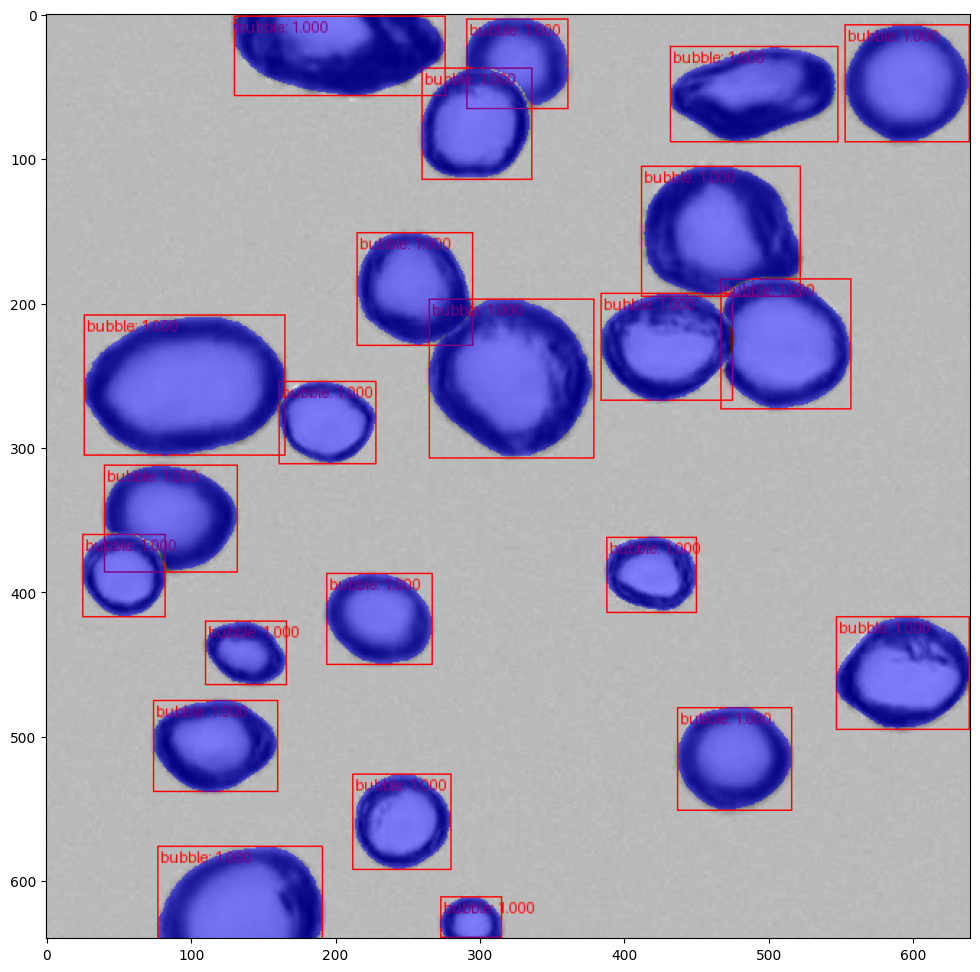

In [5]:
import matplotlib.pyplot as plt

from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks


image = read_image("../../../BubANN_GAN.v1i.coco-segmentation/test/BubGAN_0002_jpg.rf.a78f79c439aaf0c4cfcaac4ce751a071.jpg")
eval_transform = get_transform(train=False)

model.eval()
with torch.no_grad():
    x = eval_transform(image)
    # convert RGBA -> RGB and move to device
    x = x[:3, ...].to(device)
    predictions = model([x, ])
    pred = predictions[0]


image = (255.0 * (image - image.min()) / (image.max() - image.min())).to(torch.uint8)
image = image[:3, ...]
pred_labels = [f"bubble: {score:.3f}" for label, score in zip(pred["labels"], pred["scores"])]
pred_boxes = pred["boxes"].long()
output_image = draw_bounding_boxes(image, pred_boxes, pred_labels, colors="red")

masks = (pred["masks"] > 0.7).squeeze(1)
output_image = draw_segmentation_masks(output_image, masks, alpha=0.5, colors="blue")


plt.figure(figsize=(12, 12))
plt.imshow(output_image.permute(1, 2, 0))

Load Model Checkpoint (Example)
====================

In [6]:
'''
model.load_state_dict(torch.load("outputs/maskrcnn_baseline/model_epoch_3.pth"))
model.to(device)
model.eval()
'''

'\nmodel.load_state_dict(torch.load("outputs/maskrcnn_baseline/model_epoch_3.pth"))\nmodel.to(device)\nmodel.eval()\n'

Resume Training from Checkpoint (Example)
==========================================

In [7]:
'''
checkpoint = torch.load("outputs/maskrcnn_baseline/checkpoint_epoch_3.pth")
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
lr_scheduler.load_state_dict(checkpoint['lr_scheduler_state_dict'])
start_epoch = checkpoint['epoch']
'''

'\ncheckpoint = torch.load("outputs/maskrcnn_baseline/checkpoint_epoch_3.pth")\nmodel.load_state_dict(checkpoint[\'model_state_dict\'])\noptimizer.load_state_dict(checkpoint[\'optimizer_state_dict\'])\nlr_scheduler.load_state_dict(checkpoint[\'lr_scheduler_state_dict\'])\nstart_epoch = checkpoint[\'epoch\']\n'

Test Batch
=========

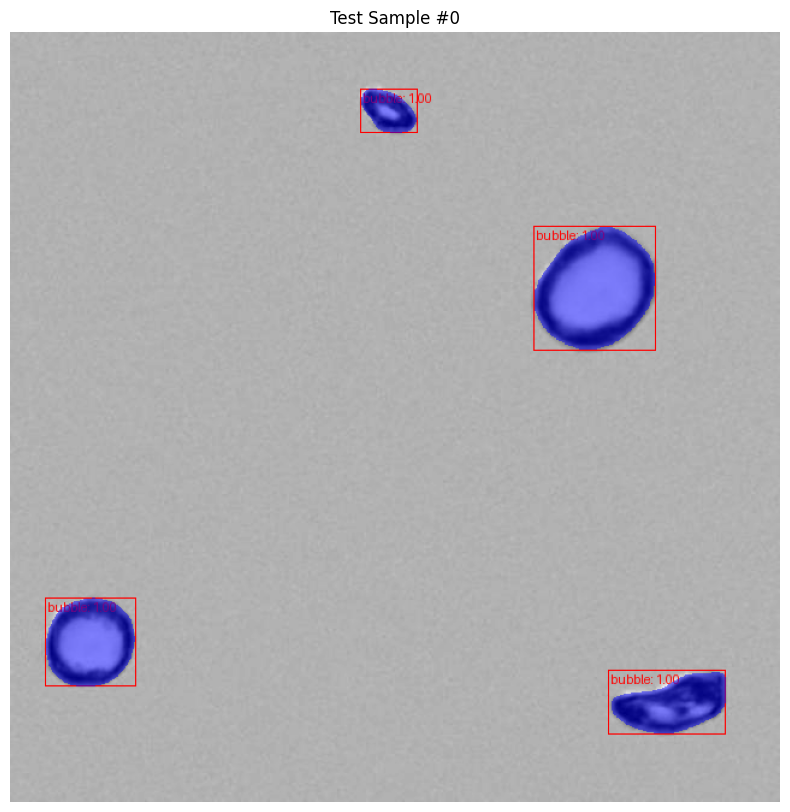

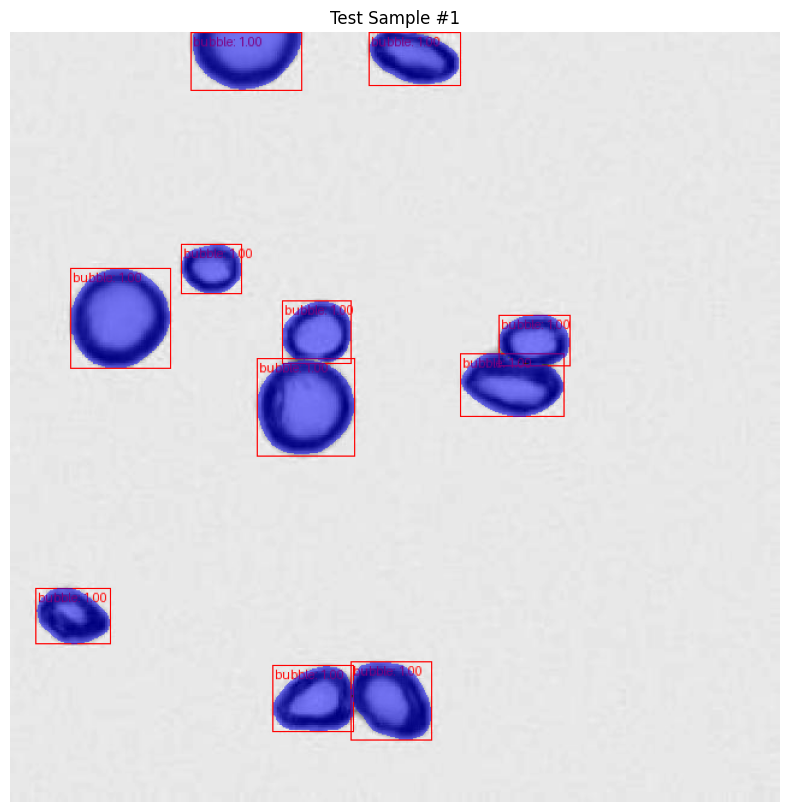

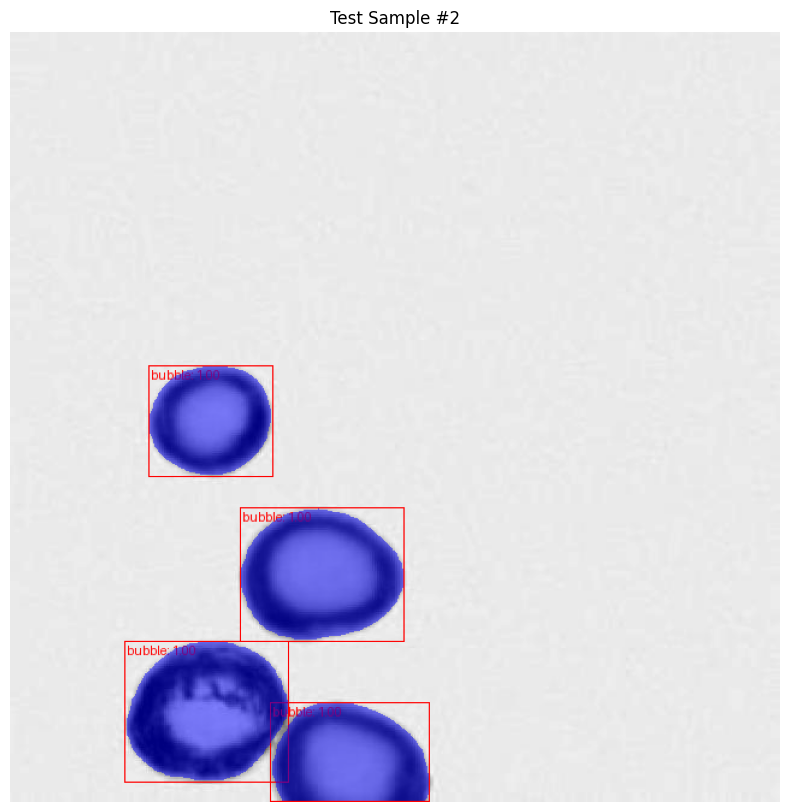

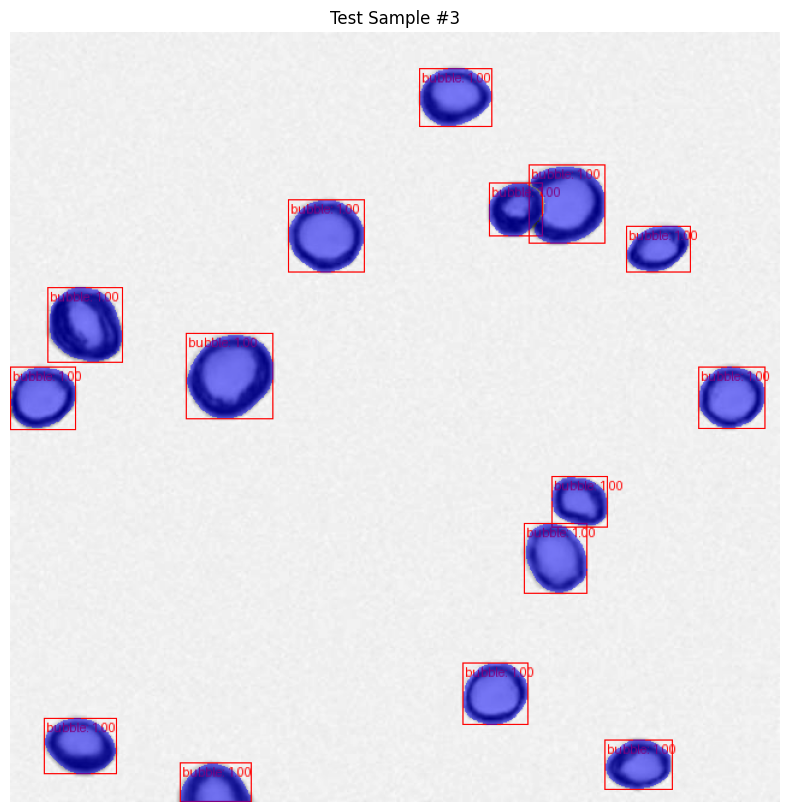

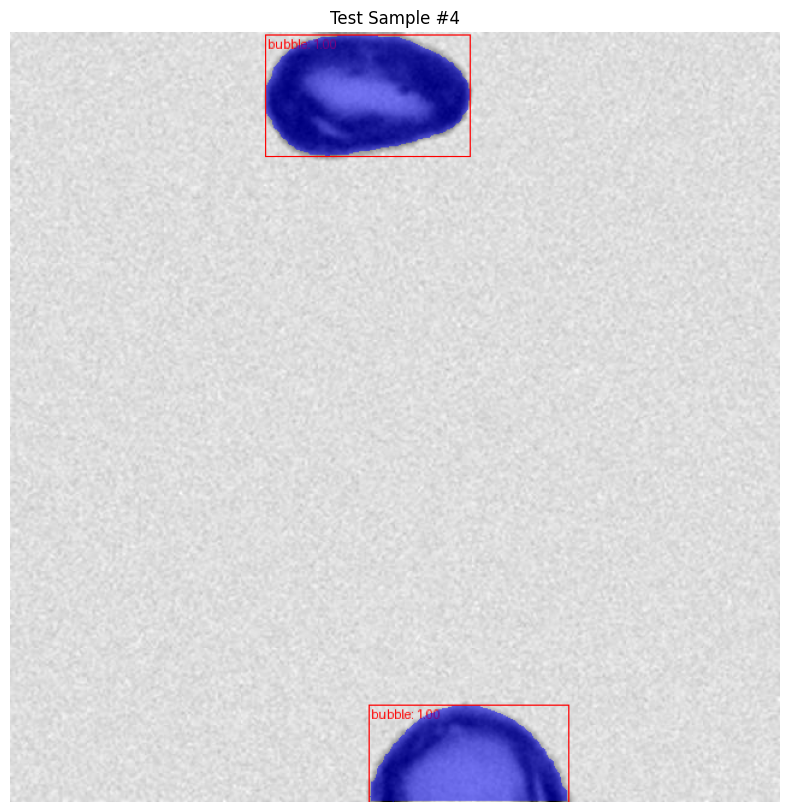

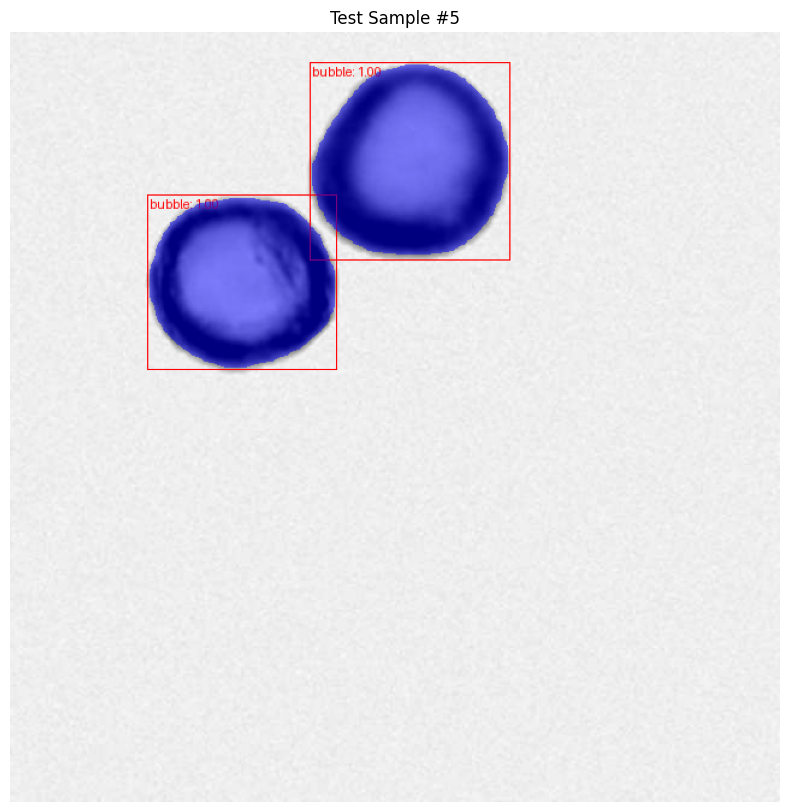

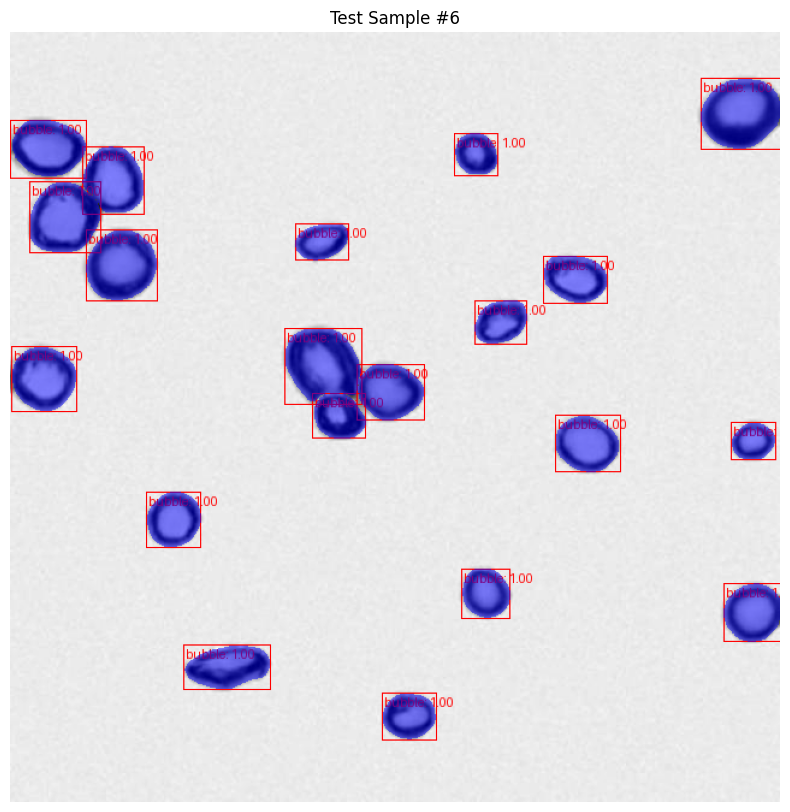

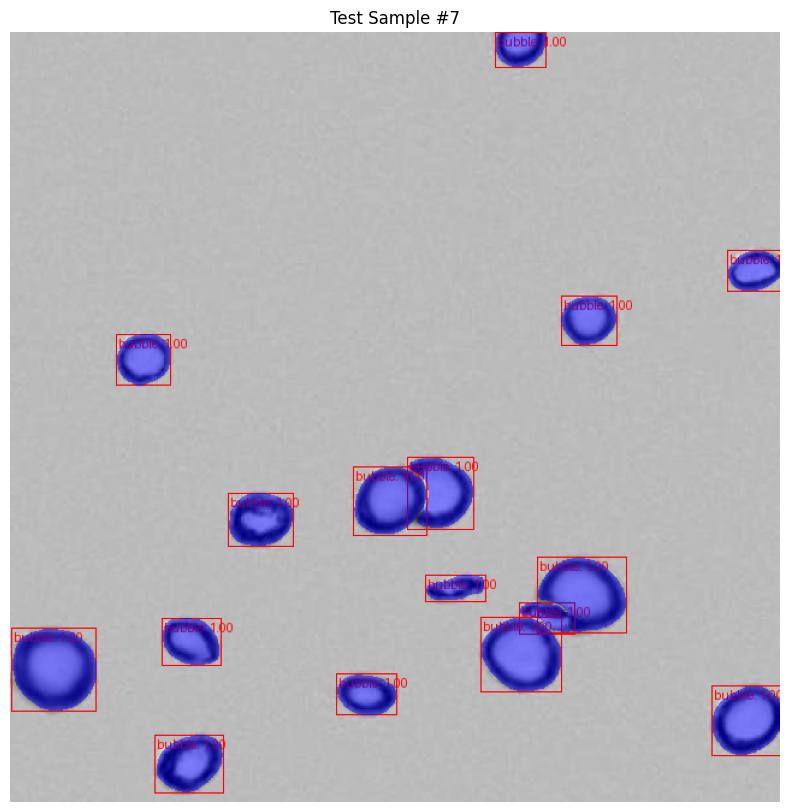

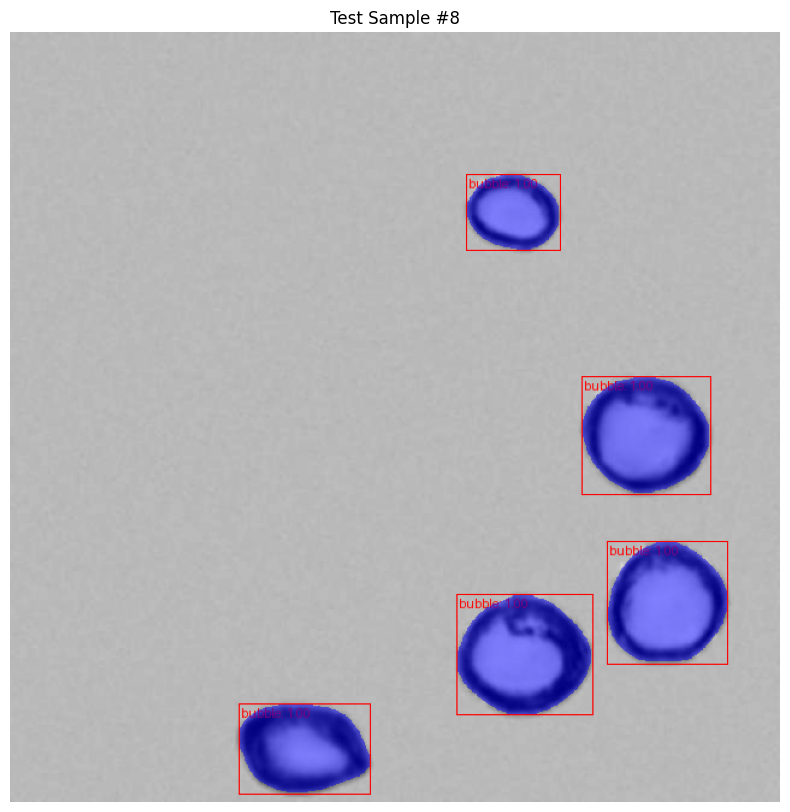

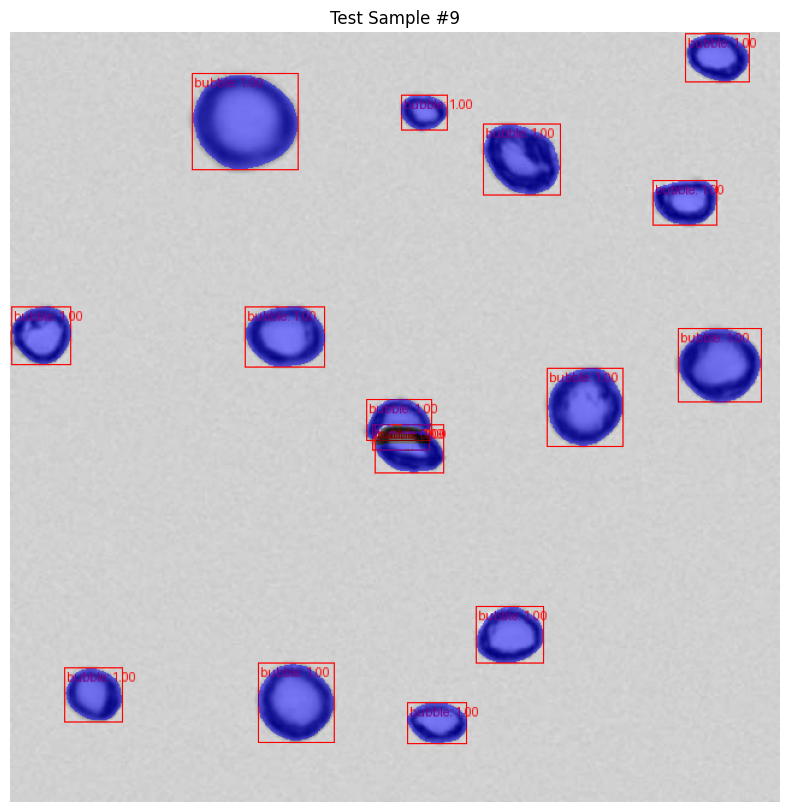

In [8]:
import matplotlib.pyplot as plt
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks
import torchvision.transforms.functional as F
import torch

model.eval()

# Number of test images to visualize
N = 10

with torch.no_grad():
    for idx, (image, target) in enumerate(data_loader_test):
        if idx >= N:
            break

        x = image[0].to(device)  # batch size = 1
        x = x[:3, ...]  # Remove alpha channel if present

        pred = model([x])[0]




        # Rescale image for visualization
        x_cpu = x.cpu()
        vis_img = (255.0 * (x_cpu - x_cpu.min()) / (x_cpu.max() - x_cpu.min())).to(torch.uint8)

        pred_labels = [f"bubble: {score:.2f}" for score in pred["scores"]]
        pred_boxes = pred["boxes"].cpu().long()
        masks = (pred["masks"].cpu() > 0.7).squeeze(1)

        output_image = draw_bounding_boxes(vis_img, pred_boxes, pred_labels, colors="red")
        output_image = draw_segmentation_masks(output_image, masks, alpha=0.5, colors="blue")

        # Plot
        plt.figure(figsize=(10, 10))
        plt.imshow(output_image.permute(1, 2, 0))
        plt.axis("off")
        plt.title(f"Test Sample #{idx}")
        plt.show()
